# Fit and save XGBoost SHAP models

## Import libraries

In [ ]:
# Turn warnings off to keep notebook tidy
import warnings
warnings.filterwarnings("ignore")

import os
import mat`h
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import shap

from dataclasses import dataclass
from sklearn.metrics import auc
from sklearn.metrics import roc_curve
from xgboost import XGBClassifier

## General settings

In [2]:
# K folds in data
n_kfold = 5
# Disability thresholds for binary classification models
list_binary_thresholds = [0, 1, 2, 3, 4, 5]
n_binary_models = len(list_binary_thresholds)
# Surrogate time for no thrombolysis (for SHAP dependence plots)
surrogate_time_for_no_thrombolysis = 9999

File paths

In [3]:
@dataclass(frozen=True)
class Paths:
    '''Singleton object for storing paths to data and database.'''
    image_save_path: str = './saved_images'
    model_save_path: str = './saved_models'
    data_save_path: str = './saved_data'
    data_read_path: str = './data_processing/output/kfold_5fold'
    model_text: str = (f'xgb_{n_kfold}fold_binary_model')
    notebook: str = '02_' # Prefix to file name

paths = Paths()

## Features to use

In [4]:
# Features to use
selected_features = ["prior_disability", "stroke_severity", "stroke_team", "age", 
                     "onset_to_thrombolysis_time", "any_afib_diagnosis", "precise_onset_known"]

# Feature name dictionary for plotting
dict_feature_names = {}
dict_feature_names["prior_disability"] = "Prior disability (mRS)"
dict_feature_names["stroke_severity"] = "Stroke severity (NIHSS)"
dict_feature_names["stroke_team"] = "Stroke team"
dict_feature_names["age"] = "Age (years)"
dict_feature_names["onset_to_thrombolysis_time"] = "Onset to thrombolysis time (minutes)"
dict_feature_names["any_afib_diagnosis"] = "Atrial fibrilation diagnosis"
dict_feature_names["precise_onset_known"] = "Precise onset time known"
dict_feature_names['discharge_disability'] = "Discharge disabiliity (mRS)"

# Number of features
n_features = len(selected_features)

# Target feature
target_feature = 'discharge_disability'

## Load data

In [5]:
X_train_kfold, y_train_kfold, X_test_kfold, y_test_kfold = [], [], [], []

for k in range(n_kfold):
    # Read in training set, restrict to chosen features & store
    filename = os.path.join(paths.data_read_path, ('train_' + str(k) + '.csv'))
    train = pd.read_csv(filename)
    X_train = train[selected_features]
    y_train = train[target_feature]
    X_train_kfold.append(X_train)
    y_train_kfold.append(y_train)

    # Read in test set, restrict to chosen features & store
    filename = os.path.join(paths.data_read_path, 
                            ('test_' + str(k) + '.csv'))
    test = pd.read_csv(filename)
    X_test = test[selected_features]
    y_test = test[target_feature]
    X_test_kfold.append(X_test)
    y_test_kfold.append(y_test)

## One-hot encode categorical features

In [6]:
def convert_feature_to_one_hot(df, feature_name, prefix):
    """
    Converts a categorical feature into a one hot encoded feature
    
    Args:
        df [dataframe]: training or test dataset
        feature_name [str]: feature to convert to one hot encoding
        prefix [str]: string to use on new feature

    Return:
        df [dataframe]: One hot encoded representation of the feature
    """

    # One hot encode a feature
    df_feature = pd.get_dummies(
        df[feature_name], prefix=prefix)
    df = pd.concat([df, df_feature], axis=1)
    df.drop(feature_name, axis=1, inplace=True)

    return(df)

In [7]:
def convert_feature_to_one_hot(df, feature_name, prefix):
    """
    Converts a categorical feature into a one hot encoded feature
    
    Args:
        df [dataframe]: training or test dataset
        feature_name [str]: feature to convert to one hot encoding
        prefix [str]: string to use on new feature

    Return:
        df [dataframe]: One hot encoded representation of the feature
    """

    # One hot encode a feature
    df_feature = pd.get_dummies(
        df[feature_name], prefix=prefix)
    df = pd.concat([df, df_feature], axis=1)
    df.drop(feature_name, axis=1, inplace=True)

    return(df)

Keep copy of original data, with 'Stroke team' not one-hot encoded

In [8]:
train_stroke_team_kfold, test_stroke_team_kfold = [], []
for k in range(n_kfold):
    train_stroke_team_kfold.append(X_train_kfold[k]["stroke_team"].values)
    test_stroke_team_kfold.append(X_test_kfold[k]["stroke_team"].values)

For both train and test dataset, convert "stroke_team" feature to one hot encoded.

In [9]:
feature = "stroke_team"
prefix = "team"
for k in range(n_kfold):
    if feature in list(X_train):
        X_train_kfold[k] = convert_feature_to_one_hot(X_train_kfold[k], feature, prefix)
        X_test_kfold[k] = convert_feature_to_one_hot(X_test_kfold[k], feature, prefix)

Feature names with one hot encoding (using data for kfold0)

In [10]:
feature_names_ohe = list(X_train_kfold[0])
n_features_ohe = len(feature_names_ohe)

In [11]:
print(f"There are {len(selected_features)} original features "
      f"(before one-hot encoding)")
print(f"There are {n_features_ohe} features (after one-hot encoding)")

There are 7 original features (before one-hot encoding)
There are 124 features (after one-hot encoding)


## Create data frames for each disability threshold

In [12]:
def create_df_of_binary_target_features(target_feature_data, binary_thresholds):
    """ 
    Given a feature, return a dataframe of all of the different binary versions 
    depending on the threshold used

    Args:
        data [dataframe]: patient feature values
        target_feature [string]: feature name of target feature
        binary_thresholds [list]: list of thresholds to use for each version of 
                    a binary target feature

    Return:
        df [dataframe]: row per instance, column per threshold. Containing 
        feature values for patients with binary representation of the target 
        feature, based on the threshold value 
    
    """    
    df = pd.DataFrame()

    for threshold in binary_thresholds:
        binary_target_feature_name = f'{target_feature}_bin_{threshold}'

        # For the new feature, set all to 0    
        df[binary_target_feature_name] = 0

        # Then set to 1 those patients that are the threshold value or less
        df[binary_target_feature_name] = (
                                    (target_feature_data <= threshold) * 1)
        
    return(df)

Create dataframe of the binary target features, store in a list per kfold.

In [13]:
list_df_all_y_bin_train_kfold, list_df_all_y_bin_test_kfold = [], []

for k in range(n_kfold):
    list_df_all_y_bin_train_kfold.append(create_df_of_binary_target_features(
                                    y_train_kfold[k], list_binary_thresholds))
    list_df_all_y_bin_test_kfold.append(create_df_of_binary_target_features(
                                    y_test_kfold[k], list_binary_thresholds))

## Load models

In [14]:
models=dict()
for binary_threshold in list_binary_thresholds:
    for k in range(n_kfold):
        # Load pickled model
        filename = os.path.join(paths.model_save_path, 
                                    (paths.notebook + paths.model_text +  "_mrs" +
                                    str(binary_threshold) + '_kfold' + str(k) + '.p'))
        with open(filename, 'rb') as file:
            models[(binary_threshold, k)] = pickle.load(file)

## Load SHAP models

In [15]:
dict_shap = {}

for binary_threshold in list_binary_thresholds:
    for k in range(n_kfold):
        filename = os.path.join(
            paths.model_save_path,
            paths.notebook + paths.model_text + "_shap_model" + str(binary_threshold) + "_kfold" + str(k) + ".p"
        )

        # Load saved SHAP explainer
        with open(filename, "rb") as file:
            dict_shap[(binary_threshold, k)] = pickle.load(file)


### Test loaded models

In [16]:
def calculate_predicted_probabilities(model, X_data):
    """ 
    Given a model and input data, return the models probability and prediction
    for each instance.
    
    Args:
        model [xgboost classifier object]: trained model
        X_data [dataframe]: input features for model

    Return:
        y_probs [array]: the probability of being in each target feature class
        y_pred [array]: the prediction (the class with the largest probability)
    """

    # Get and store predicted probabilities
    y_probs = model.predict_proba(X_data)

    # Get and store predicted class
    y_pred = model.predict(X_data)

    return(y_probs, y_pred)

In [17]:
# Store all the results for the binary model (for the 5 kfolds)
dict_binary_model_results = {}

# Include the new binary feature we calculate (replaces the multiclass feature)
for binary_threshold in list_binary_thresholds:
    # Set up the target feature name for this threshold
    binary_target_feature_name = f'{target_feature}_bin_{binary_threshold}'

    # Initialise lists
    y_pred_binary_kfold = []
    y_probs_binary_kfold = []
    shap_values_extended_kfold = []
    model_kfold = []
    model_dict = dict()
    accuracy_kfold = []
    feature_importance_kfold = []
    rocauc_kfold = []
    y_bin_test_kfold = []
    y_bin_train_kfold = []
    y_error_kfold = []

    for k in range(n_kfold):

       # Get target feature for this threshold
       y_bin_train_kfold.append(list_df_all_y_bin_train_kfold[k][binary_target_feature_name])

       ## Select XGBoost model
       model_kfold.append(models[(binary_threshold, k)])

       # Store predictions for test dataset
       (y_probs, y_pred) = calculate_predicted_probabilities(model_kfold[k], X_test_kfold[k])
       y_pred_binary_kfold.append(y_pred)
       y_probs_binary_kfold.append(y_probs[:,1])
       
        # Get ROC AUC
       y_bin_test_kfold.append(list_df_all_y_bin_test_kfold[k][binary_target_feature_name])
       fpr, tpr, thresholds = roc_curve(y_bin_test_kfold[k], y_probs[:,1])
       rocauc_kfold.append(auc(fpr, tpr))

       # Calculate error
       y_error_kfold.append(y_bin_test_kfold[k] - y_pred)
       accuracy_kfold.append(np.mean(y_error_kfold[k]==0))

       # Get and store feature importances
       feature_importance_kfold.append(model_kfold[k].feature_importances_)

       # Get SHAP values (from saved Tree Explainer model)
       shap_model = dict_shap[(binary_threshold, k)]#
       extended_shap_values = shap_model(X_test_kfold[k])
       shap_values_extended_kfold.append(extended_shap_values)

    # Print accuracy summary
    accuracy_mean = np.mean(accuracy_kfold)
    rocauc_mean =  np.mean(rocauc_kfold)
    threshold_index = list_binary_thresholds.index(binary_threshold)

    print(f"Model using binary threshold {binary_threshold}:")
    print (f'Accuracy: {accuracy_mean:0.3f} '
           f'(std across {n_kfold} kfolds: {np.std(accuracy_kfold):0.3f})')

    print (f'ROC AUC: {rocauc_mean:0.3f} '
           f'(std across {n_kfold} kfolds: {np.std(rocauc_kfold):0.3f})')
 
    print()

    # Save kfold results in dictionary for this threshold
    dict_binary_model_results[f"accuracy_kfold_list_mrs{binary_threshold}"] = accuracy_kfold
    dict_binary_model_results[f"rocauc_kfold_list_mrs{binary_threshold}"] = rocauc_kfold
    dict_binary_model_results[f"y_pred_kfold_list_mrs{binary_threshold}"] = y_pred_binary_kfold
    dict_binary_model_results[f"y_probs_kfold_list_mrs{binary_threshold}"] = y_probs_binary_kfold
    dict_binary_model_results[f"shap_values_extended_kfold_list_mrs{binary_threshold}"] = shap_values_extended_kfold
    dict_binary_model_results[f"model_kfold_list_mrs{binary_threshold}"] = model_kfold
    dict_binary_model_results[f"feature_importance_kfold_list_mrs{binary_threshold}"] = feature_importance_kfold
    dict_binary_model_results[f"y_bin_test_kfold_list_mrs{binary_threshold}"] = y_bin_test_kfold 
    dict_binary_model_results[f"y_bin_train_kfold_list_mrs{binary_threshold}"] = y_bin_train_kfold
    dict_binary_model_results[f"y_error_kfold_list_mrs{binary_threshold}"] = y_error_kfold

Model using binary threshold 0:
Accuracy: 0.882 (std across 5 kfolds: 0.001)
ROC AUC: 0.853 (std across 5 kfolds: 0.002)

Model using binary threshold 1:
Accuracy: 0.775 (std across 5 kfolds: 0.001)
ROC AUC: 0.852 (std across 5 kfolds: 0.002)

Model using binary threshold 2:
Accuracy: 0.800 (std across 5 kfolds: 0.001)
ROC AUC: 0.876 (std across 5 kfolds: 0.001)

Model using binary threshold 3:
Accuracy: 0.843 (std across 5 kfolds: 0.001)
ROC AUC: 0.890 (std across 5 kfolds: 0.002)

Model using binary threshold 4:
Accuracy: 0.882 (std across 5 kfolds: 0.001)
ROC AUC: 0.893 (std across 5 kfolds: 0.001)

Model using binary threshold 5:
Accuracy: 0.896 (std across 5 kfolds: 0.001)
ROC AUC: 0.868 (std across 5 kfolds: 0.002)



Show example SHAP

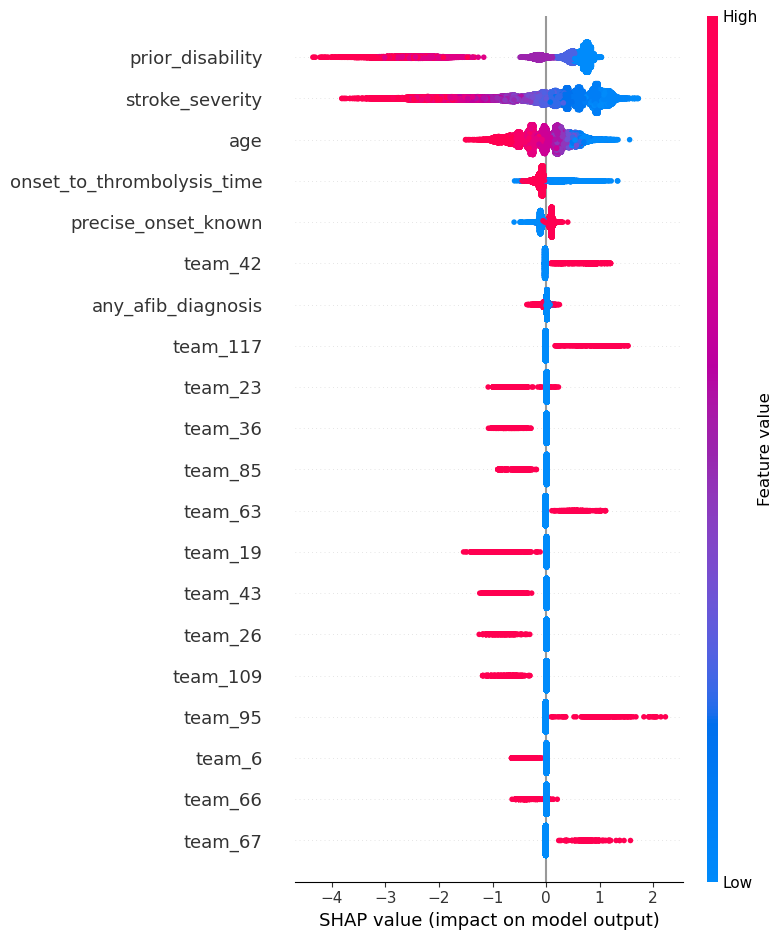

In [18]:
# Get SHAP model for binary threshold 2 and kfold 0 (as an example)
binary_threshold = 2
k = 0
shap_model = dict_shap[(binary_threshold, k)]
# Get SHAP values for test set
shap_values = shap_model.shap_values(X_test_kfold[k])
# Show SHAP plot
shap.summary_plot(shap_values, X_test_kfold[k], feature_names=feature_names_ohe)

## Violin plots for SHAP values vs feature values (and a histogram for stroke team feature)

Show the results of a binary model per column.

In [19]:
def set_ax(ax, category_list, feat, rotation=0, fontsize_axislabels=12, 
           fontsize_ticks=7):
    '''
    ax [matplotlib axis object] = matplotlib axis object
    category_list [list] = used for the xtick labels (the grouping of the data)
    feat [string] = used in the axis label, the feature that is being plotted
    rotation [integer] = xtick label rotation

    reeturn [matplotlib axis object]
    
    resource: 
    https://matplotlib.org/3.1.0/gallery/statistics/customized_violin.html
    '''
    # Set the axes ranges and axes labels
    ax.get_xaxis().set_tick_params(direction='out')
    ax.xaxis.set_ticks_position('bottom')
    ax.set_xticks(np.arange(1, len(category_list) + 1))
    ax.set_xticklabels(category_list, rotation=rotation, fontsize=fontsize_ticks)
    ax.set_xlim(0.25, len(category_list) + 0.75)
    ax.set_ylabel(f'SHAP values for {feat}', fontsize=fontsize_axislabels)
    ax.set_xlabel(f'Feature values for {feat}', fontsize=fontsize_axislabels)
    return(ax)

In [20]:
def set_each_subplot_same_range_per_row(fig, r, c):
    if c > 1:
        axs = fig.axes
        # Adjust the subplots
        for row in range(r):
            y_min = 999
            y_max = -999  
            # Through each subplot in this row (through columns)
            for col in range(c):
                ax = axs[(row * c) + col]
                y_min = min(y_min,ax.get_ylim()[0])
                y_max = max(y_max,ax.get_ylim()[1])
            for col in range(c):
                ax = axs[(row * c) + col]
                ax.set_ylim(y_min, y_max)
    return(fig)

In [21]:
def violin_plots_compare_models(list_binary_thresholds,
                                list_violin_features, 
                                list_shap_values_extended,
                                k, dict_feature_names,
                                equal_steps=True):

    # Feature Age needs special consideration. It needs the x ticks to be created,
    # as the other features with over 50 unique values, but age is already grouped 
    # for the model (into 5yr groups) and so is treated as the other type.

    # figure height depends on number of features, width on number of models
    max_features = len(list_violin_features)
    height = 7 * max_features
    n_models = len(list_binary_thresholds)
    width = 6 * n_models

    # Determine number of rows of subplots by rounding up
    ncols = n_models
    nrows = max_features

    # Create figure
    # "squeeze=False": forces a 2D axs return (even if only one row or column)
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(width,height), 
                            squeeze=False)
    fig.suptitle(
            f'Model to predict whether patient has a good outcome', 
            fontsize=20)

    # A subplot showing violin plot for a feature, from dfferent models.
    # First prepare the fature data for the violin plot: if feature has more than 
    # 50 unique values then assume it needs to be binned (a violin for each bin)

    # Comparing n models (a column of subplots per model)

    for binary_threshold in list_binary_thresholds:

        shap_values_extended = list_shap_values_extended[binary_threshold]
        base_value = round(shap_values_extended.base_values[0],3)
        if binary_threshold==0:
            title = (f"Good outcome: mRS{binary_threshold}\n"
                    f"(SHAP base value: {base_value})")
        else:
            title = (f"Good outcome: mRS0-{binary_threshold}\n"
                     f"(SHAP base value: {base_value})")

        # Through each feature
        for n, feat in enumerate(list_violin_features):   
            #subplot = ((n_models*n)+i)+1
            
            # Get data and SHAP values
            feature_data = shap_values_extended[:, feat].data
            feature_shap = shap_values_extended[:, feat].values

            # If feature has more that 50 unique values, then assume it needs
            #  to be binned (otherwise assume they are unique categories)

            if np.unique(feature_data).shape[0] > 50:
                # bin the data, create a violin per bin
                
                # settings for the plot
                rotation = 45
                if (feat == "onset_to_thrombolysis_time") or (feat == "scan_to_thrombolysis_time"):
                    value_without_negative = np.delete(feature_data, np.where(feature_data < 0))
                    value_without_negative = np.delete(feature_data, np.where(feature_data == surrogate_time_for_no_thrombolysis))
                    if equal_steps == True:
                        np.min(value_without_negative)
                        np.max(value_without_negative)
                        step = 0.10
                        # Using np.round() and tolist() to force the values to be floats
                        # with 1dp
                        bins = np.round(np.arange(np.min(value_without_negative), 
                                                  np.max(value_without_negative), 
                                                  step * (np.max(value_without_negative) - np.min(value_without_negative))),1)
                    else:
                        # Equal count
                        (res, bins) = pd.qcut(value_without_negative.astype(float), q=10, retbins=True)


                    # Bin limits are such that the value needs to be less than the upper limit, else they go into the next bin.
                    # Need to add a small value to the surrogate no treatment value to make sure that 999999 is selected for the final violin
                    # Need to add a small value to the maximum treatment time (excluding the surrogate no treatment value) to make sure that is it selected for the penultimate, and not the final, violin
                    bin_list = bins.tolist()
                    bin_list[-1] = bin_list[-1] + 0.01
                    bin_list.append(surrogate_time_for_no_thrombolysis + 0.01)
                    n_bins = len(bin_list)-2

                else:

                    step = 30
                    n_bins = min(11, np.int((feature_data.max())/step))
                    
                    # create list of bin values
                    bin_list = [(i*step) for i in range(n_bins)]
                    bin_list.append(feature_data.max())

                # Number of instances per bin
                counts, edges = np.histogram(feature_data, bins=bin_list, density=False)

                if (feat == "onset_to_thrombolysis_time") or (feat == "scan_to_thrombolysis_time"):
                    category_list = [f'{int(bin_list[i])}-{int(bin_list[i+1])}\n[n={int(counts[i])}]' for i in range(n_bins)]
                    category_list.append(f'Not receive IVT\n[n={int(counts[-1])}]')
                else:
                    # create list of bins (the unique categories)
                    category_list = [f'{int(bin_list[i+1])}-{int(bin_list[i+2])}\n[n={int(counts[i+1])}]' for i in range(n_bins-1)]
                    category_list.append(f'{int(bin_list[-2])}+\n[n={int(counts[-1])}]')


                # bin the feature data
                feature_data = pd.cut(feature_data, bin_list, labels=category_list, 
                                      right=False)

                # create a list, each entry contains the corresponsing SHAP value for that 
                # category (or bin). A violin will represent each list.    
                shap_per_category = []
                for category in category_list:
                    mask = feature_data == category
                    shap_per_category.append(feature_shap[mask])

            else:
                # create a violin per unique value
                
                # settings for the plot
                rotation = 90
                
                # create list of unique categories in the feature data
                category_list = np.unique(feature_data)

                # Age needs to keep its decimal value (midpoint between 5 yrs)
                if feat != 'age':
                    # category_list = [int(i) for i in category_list]
                    # Account for nan in the NIHSS features (ignore and include them)
                    category_list = [int(i) if not np.isnan(i) else i for i in category_list]
                    # Account for nan in the NIHSS features (ignore and exclude them)
                    # category_list = [int(i) for i in category_list if not np.isnan(i)]
                    
                # create a list, each entry contains the corresponsing SHAP value for that 
                # category (or bin). A violin will represent each list.    
                count = []
                shap_per_category = []
                for category in category_list:
                    mask = feature_data == category
                    shap_per_category.append(feature_shap[mask])
                    count.append(mask.sum())
    #                if feat == 'stroke_severity':
    #                    print(feature_shap[mask].max())

                if feat == 'age':
                    # create text of x ticks
                    category_list = [f'{int(i-2.5)}-{int(i+2.5)}' for 
                                                        i in category_list]

                    # SSNAP dataset had oldest age category as 100-120 (not a 5 yr band as 
                    #   the other ages). To accommodate this, if last age category is "110"
                    #   then overwrite the label with the correct band (100-120), and not
                    #   107-112 as the above code would create.
                    if category_list[-1] == '107-112':
                        category_list[-1] = '100-120'
                if feat == 'stroke_severity':
                    # not enough space of chart for 2 lines fo x tick labels
                    category_list = [f'{category_list[i]} [n={count[i]}]' for 
                                                i in range(len(category_list))]
                else:
                    category_list = [f'{category_list[i]}\n[n={count[i]}]' for 
                                                i in range(len(category_list))]

            # create violin plot
            ax = axs[n][binary_threshold]
            nans = [float('nan'), float('nan')]
            # For the case where there is an empty array for a violin
            ax.violinplot([val if val.any() else nans for val in shap_per_category],
                           showmeans=True, widths=0.9, showextrema=False)

            # Add line at Shap = 0
            feature_values = shap_values_extended[:, feat].data
            ax.plot([0, len(feature_values)], [0,0],c='0.5')   

            # customise the axes
            ax = set_ax(ax, category_list, dict_feature_names[feat], 
                        rotation=rotation)
            plt.subplots_adjust(bottom=0.15, wspace=0.05)
            ax.tick_params(axis='both', which='major', labelsize=16)

            # Adjust stroke severity tickmarks
            if feat == 'Stroke severity':
                ax.set_xticks(np.arange(1, len(category_list)+1, 2))
                ax.set_xticklabels(category_list[0::2])   
                
            # Add title
            if len(list_violin_features) == 1:
                ax.set_title(f'{title}')
            else:
                ax.set_title(f'{title} \n Feature: {dict_feature_names[feat]}')

    # Subplots on same row have same y range
    fig = set_each_subplot_same_range_per_row(fig, nrows, ncols)

    space_for_suptitle = 1 - (max_features * 0.005/5)
    plt.tight_layout(pad=2, rect=[0, 0, 1, space_for_suptitle])
    
    filename = os.path.join(paths.image_save_path, (paths.notebook + 
                            paths.model_text + '_shap_violin_' + str(k) + 
                            'kfold_.jpg'))
    
    fig.savefig(filename, dpi=300, bbox_inches='tight', pad_inches=0.2)

    plt.show()
    return()

In [22]:
def histograms_compare_models(list_binary_thresholds,
                              list_unique_stroketeams,
                              list_shap_values_extended, 
                              k, 
                              histtype='stepfilled',
                              one_plot=False):

    stroke_team_mean_shap_binary = []    
    xmin = 0
    xmax = 0

    # Use common x axis range for the hospital SHAP hitograms. 
    # First prepare the feature data and store the min and max to use across all 
    # plots
    list_titles = []
    for binary_threshold in list_binary_thresholds:

        shap_values_extended = list_shap_values_extended[binary_threshold]

        base_value = round(shap_values_extended.base_values[0],3)
        if binary_threshold==0:
            title = (f"Good outcome: mRS{binary_threshold}\n"
                    f"(SHAP base value: {base_value})")
        else:
            title = (f"Good outcome: mRS0-{binary_threshold}\n"
                     f"(SHAP base value: {base_value})")
        list_titles.append(title)

        # Get mean SHAP for stroke team when patient attending that stroke team
        stroke_team_mean_shap = []

        # If there are stroke teams
        if len(list_unique_stroketeams) > 0:
            # Loop through feature names
            for feature_name in list_unique_stroketeams:
                # Use the data column for team name as a mask for patients that attend the team (the data will be the same for all class_categories)
                mask = shap_values_extended[:, feature_name].data == 1
                # Use make to get the SHAP values for the stroke team, for the patients that attend this team
                stroke_team_shap = shap_values_extended[:, feature_name].values[mask]
                # Get mean
                mean_shap = np.mean(stroke_team_shap)
                # Store mean

                stroke_team_mean_shap.append(mean_shap)
        xmin = min(xmin,min(stroke_team_mean_shap))
        xmax = max(xmax,max(stroke_team_mean_shap))
        stroke_team_mean_shap_binary.append(stroke_team_mean_shap)

    dp = 3
    # figure height depends on number of features, width on number of models
    n_models = len(list_binary_thresholds)
    width = 5.8 * n_models

    nrows = 1
    ncols = n_models
    if one_plot:
        ncols=1
        width = 5.8

    # Create figure
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(width,6.5), 
                            constrained_layout=True)
    fig.suptitle(
            f'Models to predict whether patient has a good outcome', 
            fontsize=20)

    # histogram for stroke team SHAP for an output category, comparing models

    # Comparing n models (a column of subplots per model)
    for (binary_threshold, stroke_team_mean_shap) in zip(list_binary_thresholds,stroke_team_mean_shap_binary):

        # If there are stroke teams
        if len(list_unique_stroketeams) > 0:
            if one_plot:
                ax=axs
            else:
                if n_models == 1:
                    ax = axs                
                else:
                    ax = axs[binary_threshold]

            ax.hist(stroke_team_mean_shap, 
                    color=[0.12156863, 0.46666667, 0.70588235, 0.3], 
                    ec=[0.12156863, 0.46666667, 0.70588235, 1.], 
                    linewidth=1.4, histtype=histtype)#, bins=np.arange(-1.5, 1.5, 0.1)

            ax.set_xlabel('Mean SHAP value for hospital attended', fontsize=16)
            ax.set_ylabel('Count', fontsize=16)
            ax.tick_params(axis='both', which='major', labelsize=16)
            
        #    plt.tight_layout(pad=2, rect=[0, 0, 1, space_for_suptitle])

            # Add title
            ax.set_title(f'{list_titles[binary_threshold]}', fontsize=16)# \n Feature: stroke team')

            ax.set_xlim(xmin*1.1, xmax*1.1)
            text =('\n'.join((
                f'Mean: {round(np.mean(stroke_team_mean_shap),dp)}',
                f'Standard deviation '
                f'{round(np.std(stroke_team_mean_shap),dp)}')))

            # place a text box in upper left in axes coords
            props = dict(boxstyle='round', alpha=0.2, facecolor='white')
            ax.text(0, (-0.15), text, 
                    transform=ax.transAxes, fontsize=16, 
                    verticalalignment='top', bbox=props)


    # Subplots on same row have same y range
    fig = set_each_subplot_same_range_per_row(fig, nrows, ncols)

    
    filename = os.path.join(paths.image_save_path, (paths.notebook + 
                            paths.model_text + '_hosp_shap_hist_mrs_' + str(k) + 
                            'kfold.jpg'))
    
    plt.savefig(filename, dpi=300, bbox_inches='tight', pad_inches=0.2)
    plt.show()

    range_shap_log_odds = max(stroke_team_mean_shap) - min(stroke_team_mean_shap)
    odds = math.exp(range_shap_log_odds)
    print(f"There was a {round(odds,2)} fold difference in odds of being "
          f"classified as mRS{binary_threshold} between hospitals")
    
    return()

In [23]:
# Create a mask for feature names that don't contain string "team_"
mask_exclude_team = ['team_' not in i for i in feature_names_ohe]
mask_include_team = ['team_' in i for i in feature_names_ohe]

# Use mask to exclude features containing string "team_"
model_features = np.array(feature_names_ohe)
model_features_wo_teams = model_features[mask_exclude_team]
model_team_features = model_features[mask_include_team]

Kfold0


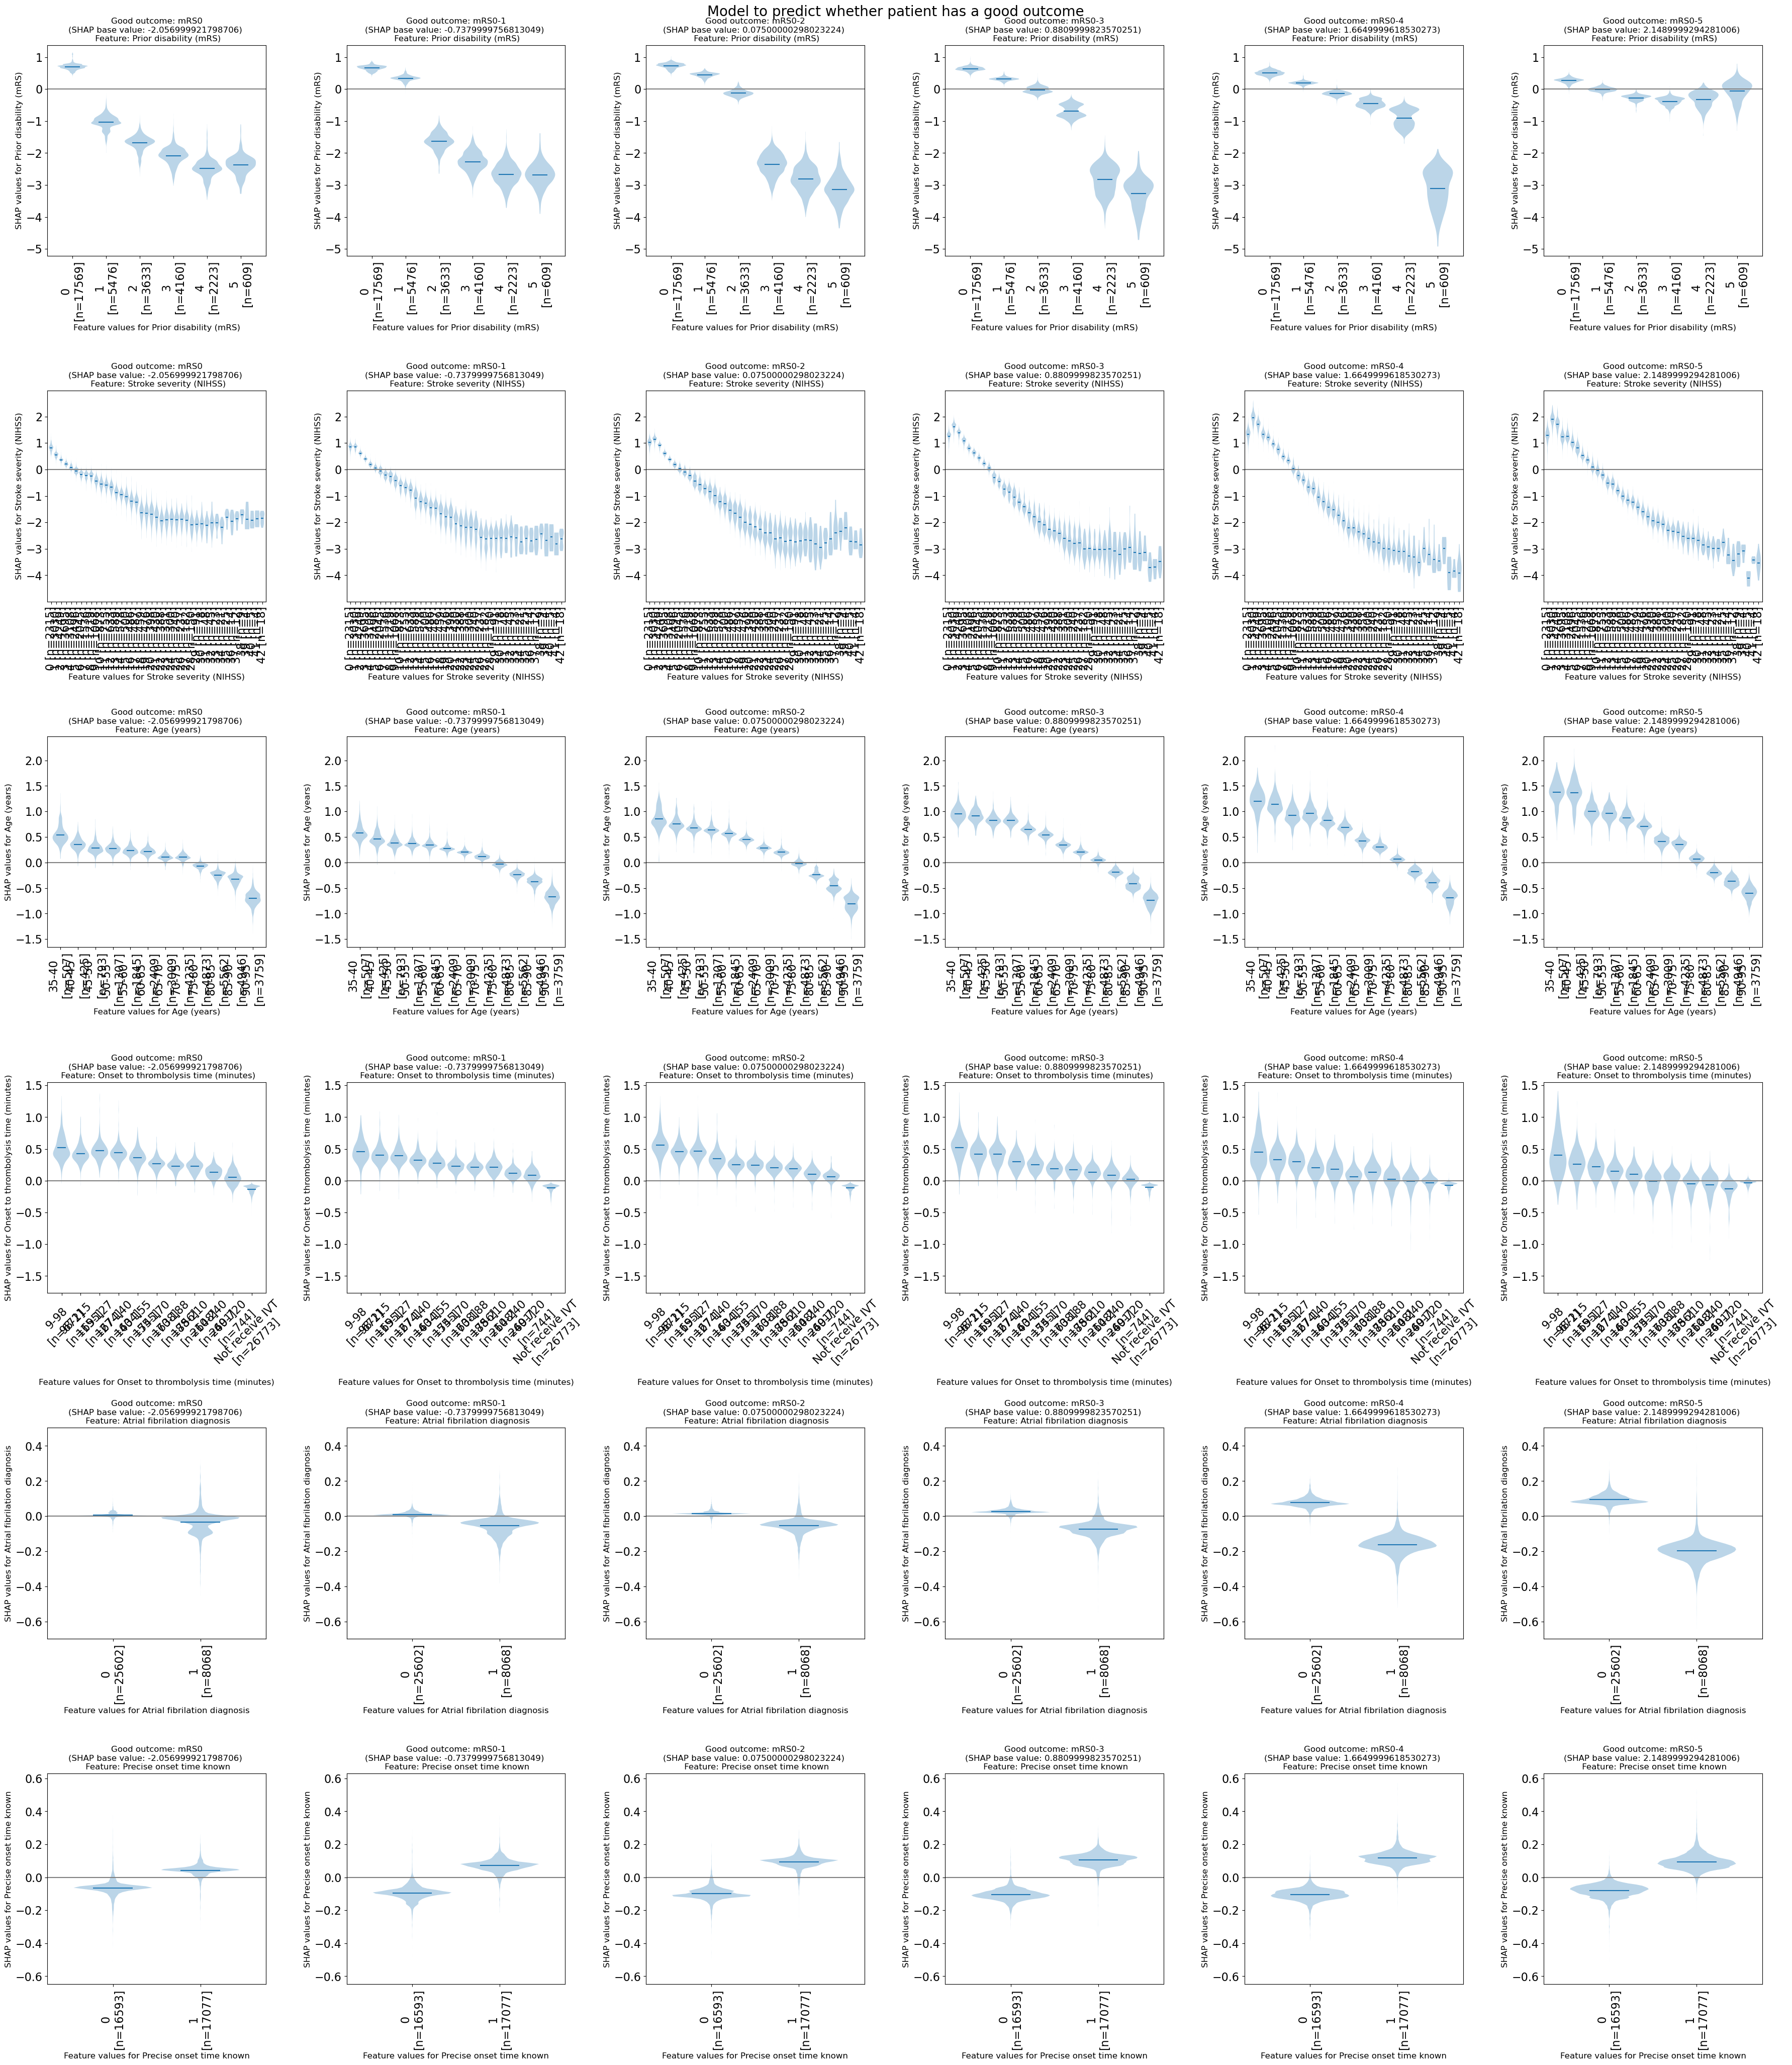

Kfold0


In [ ]:
for k in range(1): # <- replace with (n_kfold) for all 
    print(f"Kfold{k}")
    # Get values for each binary threshold, for the kfold
    list_shap_values_extended = []
    for binary_threshold in list_binary_thresholds:
        list_shap_values_extended.append(
            dict_binary_model_results[f"shap_values_extended_kfold_list_mrs{binary_threshold}"][k])

    # Violin plots of feature data vs SHAP values
    violin_plots_compare_models(list_binary_thresholds,
                                model_features_wo_teams.tolist(),
                                list_shap_values_extended,
                                k, dict_feature_names,
                                equal_steps=False)
    print(f"Kfold{k}")
    # Histogram of stroke team SHAP values
    histograms_compare_models(list_binary_thresholds,
                            model_team_features.tolist(),
                            list_shap_values_extended,
                            k)